# 2주차. Attention 이전의 자연어

In [1]:
%pip install -q torch numpy

Note: you may need to restart the kernel to use updated packages.


## 1. RNN (Recurrent Neural Network)

In [2]:
# 같은 W_x, W_h를 모든 시점에서 재사용하며 h_t를 갱신한다
import numpy as np

np.random.seed(0)
d_in, d_hidden = 4, 3

W_x = np.random.randn(d_hidden, d_in) * 0.1
W_h = np.random.randn(d_hidden, d_hidden) * 0.1

def rnn_step(x_t, h_prev):
    return np.tanh(W_x @ x_t + W_h @ h_prev)

seq = np.random.randn(5, d_in)  # 5토큰짜리 문장
h = np.zeros(d_hidden)
for t, x_t in enumerate(seq):
    h = rnn_step(x_t, h)
    print(f"t={t}  h_t = {h.round(3)}")

t=0  h_t = [ 0.527 -0.067  0.335]
t=1  h_t = [ 0.124 -0.306  0.172]
t=2  h_t = [ 0.116  0.258 -0.145]
t=3  h_t = [-0.067 -0.286  0.203]
t=4  h_t = [-0.067  0.198 -0.211]


In [3]:
# 문장이 길어져도 파라미터 수는 그대로다
import torch
import torch.nn as nn

rnn = nn.RNN(input_size=4, hidden_size=3, batch_first=True)
n_params = sum(p.numel() for p in rnn.parameters())

for seq_len in [5, 20, 100]:
    x = torch.randn(1, seq_len, 4)
    out, h_n = rnn(x)
    print(f"문장 길이 {seq_len:>3} | 출력 토큰 수 {out.shape[1]:>3} | hidden 크기 {h_n.shape[-1]} | 파라미터 수 {n_params}")


문장 길이   5 | 출력 토큰 수   5 | hidden 크기 3 | 파라미터 수 27
문장 길이  20 | 출력 토큰 수  20 | hidden 크기 3 | 파라미터 수 27
문장 길이 100 | 출력 토큰 수 100 | hidden 크기 3 | 파라미터 수 27


### 기울기 소실

RNN epoch    0 | loss 0.700 | 정확도 0.45


RNN epoch  150 | loss 0.698 | 정확도 0.47


RNN epoch  300 | loss 0.692 | 정확도 0.52


RNN epoch  450 | loss 0.692 | 정확도 0.52


RNN epoch  600 | loss 0.698 | 정확도 0.43


...

RNN epoch  900 | loss 0.700 | 정확도 0.41


RNN epoch 1050 | loss 0.688 | 정확도 0.60


RNN epoch 1200 | loss 0.700 | 정확도 0.53


RNN epoch 1350 | loss 0.692 | 정확도 0.47


RNN epoch 1499 | loss 0.687 | 정확도 0.58


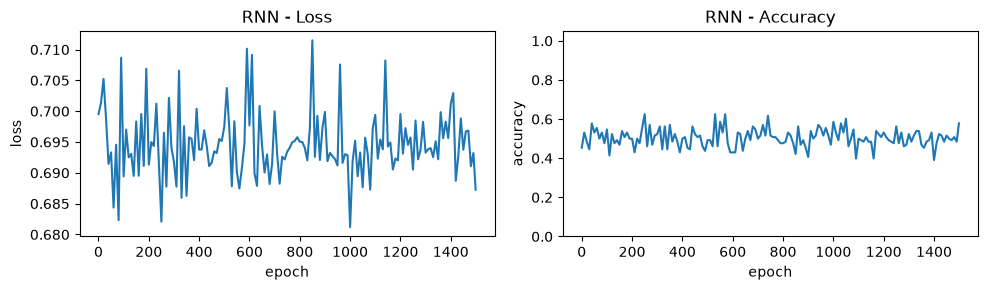

[(0, 0.6995297074317932, 0.453125),
 (10, 0.7013230919837952, 0.53125),
 (20, 0.7052335739135742, 0.484375),
 (30, 0.6988402009010315, 0.4453125),
 (40, 0.6914443373680115, 0.578125),
 (50, 0.6933173537254333, 0.53125),
 (60, 0.684364378452301, 0.5546875),
 (70, 0.6945570707321167, 0.5),
 (80, 0.6823248863220215, 0.53125),
 (90, 0.7086823582649231, 0.4765625),
 (100, 0.6894243359565735, 0.546875),
 (110, 0.6970072984695435, 0.4140625),
 (120, 0.6924996376037598, 0.5234375),
 (130, 0.6930890083312988, 0.4765625),
 (140, 0.6895021796226501, 0.4921875),
 (150, 0.6983246207237244, 0.46875),
 (160, 0.6895322203636169, 0.5390625),
 (170, 0.6995365023612976, 0.5078125),
 (180, 0.6911160945892334, 0.53125),
 (190, 0.7068811655044556, 0.5),
 (200, 0.6913360357284546, 0.5),
 (210, 0.6949936151504517, 0.4296875),
 (220, 0.694359540939331, 0.5),
 (230, 0.7012225389480591, 0.4765625),
 (240, 0.691491425037384, 0.5546875),
 (250, 0.6820840239524841, 0.625),
 (260, 0.6965091228485107, 0.4609375),
 (2

In [4]:
# 문장 맨 앞 토큰을 끝까지 기억해야 맞히는 과제로 기울기 소실을 확인한다
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

vocab_size = 2
hidden_size = 32
seq_len = 30


class Recall(nn.Module):
    def __init__(self, cell, forget_bias=False):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_size)
        self.rnn = cell(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        if forget_bias:
            for name, p in self.rnn.named_parameters():
                if "bias" in name:
                    n = p.shape[0] // 4
                    p.data[n:2 * n].fill_(1.0)  # forget gate가 잘 안 잊도록 초기화

    def forward(self, x):
        _, state = self.rnn(self.emb(x))
        h = state[0] if isinstance(state, tuple) else state
        return self.fc(h[-1])


def make_batch(bs):
    x = torch.randint(0, vocab_size, (bs, seq_len))
    y = x[:, 0].clone()  # 정답은 맨 첫 토큰
    return x, y


def plot_curves(history, title):
    epochs, losses, accs = zip(*history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(epochs, losses)
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[1].plot(epochs, accs)
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def train(model, name, epochs=1500, log_every=150, record_every=10):
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    criterion = nn.CrossEntropyLoss()
    history = []
    for epoch in range(epochs):
        x, y = make_batch(128)
        opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        if epoch % record_every == 0 or epoch == epochs - 1:
            acc = (logits.argmax(-1) == y).float().mean().item()
            history.append((epoch, loss.item(), acc))
            if epoch % log_every == 0 or epoch == epochs - 1:
                print(f"{name} epoch {epoch:>4} | loss {loss.item():.3f} | 정확도 {acc:.2f}")
    plot_curves(history, name)
    return history


torch.manual_seed(0)
rnn_model = Recall(nn.RNN)
train(rnn_model, "RNN")


## 2. LSTM (Long Short-Term Memory)

In [5]:
# 게이트가 늘어난 만큼 LSTM과 GRU는 RNN보다 파라미터가 많다
import torch.nn as nn

hidden_size = 64
input_size = 32

rnn = nn.RNN(input_size, hidden_size, batch_first=True)
lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
gru = nn.GRU(input_size, hidden_size, batch_first=True)


def count_params(m):
    return sum(p.numel() for p in m.parameters())


for name, m in [("RNN", rnn), ("LSTM", lstm), ("GRU", gru)]:
    print(f"{name:4s} 파라미터 수: {count_params(m):,}")

RNN  파라미터 수: 6,272
LSTM 파라미터 수: 25,088
GRU  파라미터 수: 18,816


In [6]:
# LSTM은 hidden state 외에 cell state도 함께 내보낸다
x = torch.randn(1, 6, input_size)
out, (h_n, c_n) = lstm(x)

print("LSTM 출력: h_n, c_n 두 개")
print("h_n 크기:", h_n.shape[-1])
print("c_n 크기:", c_n.shape[-1])


LSTM 출력: h_n, c_n 두 개
h_n 크기: 64
c_n 크기: 64


LSTM epoch    0 | loss 0.707 | 정확도 0.48


LSTM epoch  150 | loss 0.000 | 정확도 1.00


LSTM epoch  300 | loss 0.000 | 정확도 1.00


LSTM epoch  450 | loss 0.000 | 정확도 1.00


LSTM epoch  600 | loss 0.000 | 정확도 1.00


...

LSTM epoch  900 | loss 0.000 | 정확도 1.00


LSTM epoch 1050 | loss 0.000 | 정확도 1.00


LSTM epoch 1200 | loss 0.000 | 정확도 1.00


LSTM epoch 1350 | loss 0.000 | 정확도 1.00


LSTM epoch 1499 | loss 0.000 | 정확도 1.00


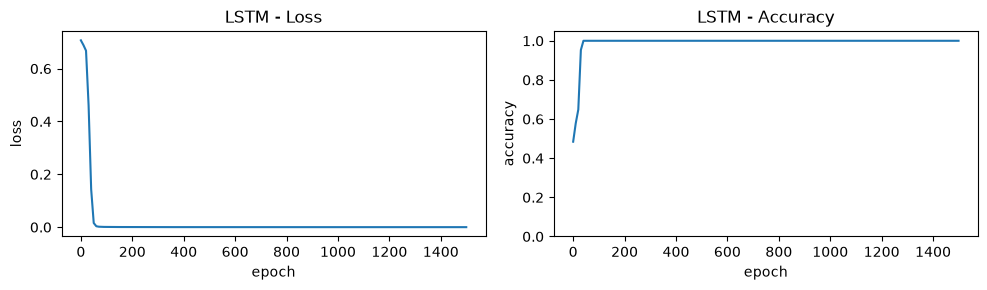

[(0, 0.7071653008460999, 0.484375),
 (10, 0.6890872716903687, 0.578125),
 (20, 0.6680112481117249, 0.6484375),
 (30, 0.46122363209724426, 0.953125),
 (40, 0.14346373081207275, 1.0),
 (50, 0.01566561684012413, 1.0),
 (60, 0.0034968561958521605, 1.0),
 (70, 0.0017021276289597154, 1.0),
 (80, 0.0011576316319406033, 1.0),
 (90, 0.000948415428865701, 1.0),
 (100, 0.0008147219195961952, 1.0),
 (110, 0.0006902911700308323, 1.0),
 (120, 0.0006829919293522835, 1.0),
 (130, 0.0005944910226389766, 1.0),
 (140, 0.0005573493544943631, 1.0),
 (150, 0.0004973144386895001, 1.0),
 (160, 0.00046084250789135695, 1.0),
 (170, 0.000434472574852407, 1.0),
 (180, 0.0003948565572500229, 1.0),
 (190, 0.00035686150658875704, 1.0),
 (200, 0.00033221658668480814, 1.0),
 (210, 0.0003198673657607287, 1.0),
 (220, 0.00029640860157087445, 1.0),
 (230, 0.00028631434543058276, 1.0),
 (240, 0.0002681944752112031, 1.0),
 (250, 0.0002546018804423511, 1.0),
 (260, 0.00023803146905265749, 1.0),
 (270, 0.00023140411940403283

In [ ]:
# 같은 과제, 같은 설정에서 RNN을 LSTM으로만 바꿔서 다시 학습시킨다
torch.manual_seed(0)
lstm_model = Recall(nn.LSTM, forget_bias=True)
train(lstm_model, "LSTM")

### GRU

In [8]:
# GRU는 cell state가 없어 LSTM보다 파라미터가 적다
lstm_params = count_params(lstm)
gru_params = count_params(gru)
print(f"LSTM 파라미터 수: {lstm_params:,}")
print(f"GRU  파라미터 수: {gru_params:,}")
print(f"GRU / LSTM 비율: {gru_params / lstm_params:.2f}")

LSTM 파라미터 수: 25,088
GRU  파라미터 수: 18,816
GRU / LSTM 비율: 0.75


### 입출력 길이 문제

In [9]:
# RNN은 입력을 몇 토큰 읽든 출력도 똑같은 개수만큼 나온다
x = torch.randn(1, 7, input_size)  # 7토큰짜리 입력
out, _ = rnn(x)
print(f"입력 토큰 수: {x.shape[1]}")
print(f"출력 개수:   {out.shape[1]}")

입력 토큰 수: 7
출력 개수:   7


## 3. Seq2Seq (Sequence-to-Sequence)

Seq2Seq epoch    0 | loss 2.296 | 정확도 0.10


Seq2Seq epoch  100 | loss 0.991 | 정확도 0.66


Seq2Seq epoch  200 | loss 0.654 | 정확도 0.78


Seq2Seq epoch  300 | loss 0.455 | 정확도 0.85


Seq2Seq epoch  400 | loss 0.321 | 정확도 0.91


...

Seq2Seq epoch 1600 | loss 0.028 | 정확도 1.00


Seq2Seq epoch 1700 | loss 0.022 | 정확도 1.00


Seq2Seq epoch 1800 | loss 0.023 | 정확도 1.00


Seq2Seq epoch 1900 | loss 0.017 | 정확도 1.00


Seq2Seq epoch 1999 | loss 0.018 | 정확도 1.00


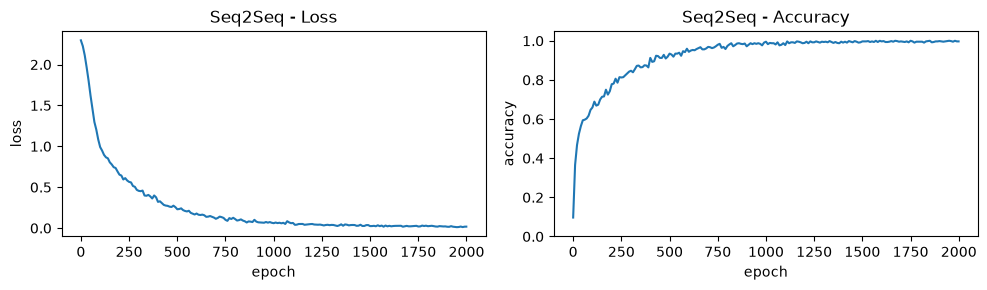

In [10]:
# 매번 다른 시퀀스를 주고, 각 토큰을 두 번씩 반복해서 내보내게 학습시킨다 (입력 5토큰 -> 출력 10토큰)
vocab_size = 10
in_len = 5
out_len = in_len * 2
embed_dim = 16
hidden_size = 32

embedding = nn.Embedding(vocab_size, embed_dim)
encoder = nn.LSTM(embed_dim, hidden_size, batch_first=True)
decoder = nn.LSTM(embed_dim, hidden_size, batch_first=True)
output_layer = nn.Linear(hidden_size, vocab_size)


def make_batch(bs):
    src = torch.randint(0, vocab_size, (bs, in_len))
    tgt = src.repeat_interleave(2, dim=1)  # 정답: 각 토큰을 두 번씩
    sos = torch.zeros(bs, 1, dtype=torch.long)
    tgt_in = torch.cat([sos, tgt[:, :-1]], dim=1)  # teacher forcing
    return src, tgt_in, tgt


params = list(embedding.parameters()) + list(encoder.parameters()) \
    + list(decoder.parameters()) + list(output_layer.parameters())
optimizer = torch.optim.Adam(params, lr=3e-3)
criterion = nn.CrossEntropyLoss()

epochs = 2000
history = []
for epoch in range(epochs):
    src, tgt_in, tgt = make_batch(64)
    optimizer.zero_grad()

    _, (context_h, context_c) = encoder(embedding(src))
    dec_out, _ = decoder(embedding(tgt_in), (context_h, context_c))
    logits = output_layer(dec_out)

    loss = criterion(logits.reshape(-1, vocab_size), tgt.reshape(-1))
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == epochs - 1:
        accuracy = (logits.argmax(-1) == tgt).float().mean().item()
        history.append((epoch, loss.item(), accuracy))
        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"Seq2Seq epoch {epoch:>4} | loss {loss.item():.3f} | 정확도 {accuracy:.2f}")

plot_curves(history, "Seq2Seq")


### 고정 길이 병목

In [11]:
# 입력이 아무리 길어져도 context 벡터의 크기는 그대로다
for seq_len in [4, 20, 100]:
    x = torch.randint(0, vocab_size, (1, seq_len))
    _, (h, _) = encoder(embedding(x))
    print(f"입력 길이 {seq_len:>3} -> context 크기 {h.shape[-1]}  (항상 동일)")


입력 길이   4 -> context 크기 32  (항상 동일)
입력 길이  20 -> context 크기 32  (항상 동일)
입력 길이 100 -> context 크기 32  (항상 동일)
